Load API Key

This cell loads the Etherscan API key from the .env file so the notebook can use it without exposing the key in the code. It checks that the key is loaded correctly and prints only the first few characters for confirmation.


In [17]:
from dotenv import load_dotenv
import os

# look for .env in the parent folder of notebooks/
load_dotenv("../.env")

API_KEY = os.getenv("ETHERSCAN_API_KEY")
print("Loaded key:", API_KEY[:6] + "..." if API_KEY else None)

Loaded key: R7NWRK...


Test Etherscan Connection

This cell sends a simple test request to the Etherscan V2 API to make sure the API key, URL, and connection all work properly. If the response is “OK”, it means it is safe to continue to fetch real on-chain data.

In [18]:
import requests

url = "https://api.etherscan.io/v2/api"

params = {
    "chainid": 1,            # Ethereum mainnet
    "module": "account",
    "action": "balance",     # super simple test
    "address": "0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640",  # any valid address works
    "tag": "latest",
    "apikey": API_KEY,       # secure key from .env
}

response = requests.get(url, params=params).json()

print(response)

{'status': '1', 'message': 'OK', 'result': '0'}


Fetch Uniswap V3 Swap Logs

This cell retrieves actual swap event logs from the Uniswap V3 USDC/WETH pool on Ethereum. It queries the blockchain for a specific block range and stores the returned logs in a DataFrame for analysis.

In [19]:
import requests
import pandas as pd

POOL_ADDRESS = "0x88e6A0c2dDD26FEEb64F039a2c41296FcB3f5640"  # Uniswap V3 USDC/WETH 0.05%

# Uniswap V3 Swap event topic
SWAP_TOPIC0 = "0xc42079f94a6350d7e6235f29174924f928cc2ac818eb64fed8004e115fbcca67"

url = "https://api.etherscan.io/v2/api"

params = {
    "chainid": 1,
    "module": "logs",
    "action": "getLogs",
    "address": POOL_ADDRESS,
    "fromBlock": 18000000,
    "toBlock": 18100000,
    "topic0": SWAP_TOPIC0,
    "page": 1,
    "offset": 1000,
    "apikey": API_KEY,
}

resp = requests.get(url, params=params).json()
print("Status:", resp.get("status"), "| Message:", resp.get("message"))

logs = resp.get("result", [])
print("Number of logs:", len(logs))

df = pd.DataFrame(logs)
df.head()

Status: 1 | Message: OK
Number of logs: 1000


,address,topics,data,blockNumber,blockHash,timeStamp,gasPrice,gasUsed,logIndex,transactionHash,transactionIndex
0,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112a881,0xd5ca78be6c6b42cf929074f502cef676372c26f8d0ba...,0x64ea269b,0x59357e7b1,0x3559a,0xbd,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,0x21
1,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a882,0x5b94c39ad7eecbf043f62a4a76c5abee87195207df98...,0x64ea26a7,0x5760a9dc4,0x377b4,0xad,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,0x2b
2,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88d,0xf68f282d1fc1e116c64443efd6ef0a0e1048bf21017d...,0x64ea272b,0x46c7cfe00,0x2ea32,0xe7,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,0x5e
3,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88f,0x943f087b63585553db2d5a45f7550e41557405aa9ab4...,0x64ea2743,0x43c08918f,0x31ab2,0x109,0x070379239598fdeaed5cf8910f87135c55783fb75778...,0x75
4,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a89d,0x6ac7fe3575dfb18c5dc8b746acd0d472e78230a30ea1...,0x64ea27eb,0x490b2770e,0x3024a,0xe9,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,0x4d


Save Logs to CSV

This cell saves the fetched logs as a CSV file in the project directory. This makes it possible to reuse the data later for cleaning, visualization, and machine learning without needing to call the API every time.

In [20]:
import os

output_path = "../data/raw/uniswap_v3_usdc_weth_swap_logs_sample.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False)

print("Saved logs to:", output_path)

Saved logs to: ../data/raw/uniswap_v3_usdc_weth_swap_logs_sample.csv


Convert hex fields to readable numbers  

This cell converts "blockNumber" and "timeStamp" from hex strings (e.g. 0x64ea269b) into normal integers, and then turn the timestamp into a human-readable datetime column. This makes it easier to understand when each swap happened.

In [21]:
import pandas as pd
# Work on a copy of the original logs
logs_clean = df.copy()

# Convert blockNumber from hex string to integer
logs_clean["blockNumber_int"] = logs_clean["blockNumber"].apply(
    lambda x: int(x, 16) if isinstance(x, str) and x.startswith("0x") else int(x)
)

# Convert timeStamp from hex string to integer seconds, then to datetime
if "timeStamp" in logs_clean.columns:
    logs_clean["timeStamp_int"] = logs_clean["timeStamp"].apply(
        lambda x: int(x, 16) if isinstance(x, str) and x.startswith("0x") else int(x)
    )
    logs_clean["timeStamp_dt"] = pd.to_datetime(logs_clean["timeStamp_int"], unit="s")

logs_clean[["blockNumber", "blockNumber_int", "timeStamp", "timeStamp_int", "timeStamp_dt"]].head()

,blockNumber,blockNumber_int,timeStamp,timeStamp_int,timeStamp_dt
0,0x112a881,18000001,0x64ea269b,1693066907,2023-08-26 16:21:47
1,0x112a882,18000002,0x64ea26a7,1693066919,2023-08-26 16:21:59
2,0x112a88d,18000013,0x64ea272b,1693067051,2023-08-26 16:24:11
3,0x112a88f,18000015,0x64ea2743,1693067075,2023-08-26 16:24:35
4,0x112a89d,18000029,0x64ea27eb,1693067243,2023-08-26 16:27:23


Decode Uniswap V3 swap event fields  

This cell extracts more meaningful information from each log.  
It decodes the "topics" field to get the "sender" and "recipient" addresses, and breaks down the hex-encoded "data" field into numeric values: "amount0", "amount1", "sqrtPriceX96", "liquidity", and "tick".  
These new columns will be the main features for later analysis and anomaly detection.

In [22]:
import numpy as np
import ast

# Convert 256-bit hex to signed integer (for amount0, amount1, tick)
def hex_to_signed_int(hex_str, bits=256):
    value = int(hex_str, 16)
    if value >= 2 ** (bits - 1):
        value -= 2 ** bits
    return value

def decode_swap_row(row):
    # Extract sender and recipient

    topics = row["topics"]

    # Check whether topics was saved as a string ,if so parse it back to a list
    if isinstance(topics, str):
        try:
            topics = ast.literal_eval(topics)
        except Exception:
            # If parsing fails, return NaNs
            return pd.Series({
                "sender": np.nan,
                "recipient": np.nan,
                "amount0": np.nan,
                "amount1": np.nan,
                "sqrtPriceX96": np.nan,
                "liquidity": np.nan,
                "tick": np.nan,
            })

    # topics[1] = sender, topics[2] = recipient
    sender = "0x" + topics[1][-40:]
    recipient = "0x" + topics[2][-40:]

    # Split into 5 x 32-byte segments

    data_hex = row["data"]
    if isinstance(data_hex, str) and data_hex.startswith("0x"):
        data_hex = data_hex[2:]  # remove '0x'

    # Each 32-byte word = 64 hex characters
    chunks = [data_hex[i:i+64] for i in range(0, len(data_hex), 64)]

    if len(chunks) < 5:
        # If something is off, return NaNs but keep sender/recipient
        return pd.Series({
            "sender": sender,
            "recipient": recipient,
            "amount0": np.nan,
            "amount1": np.nan,
            "sqrtPriceX96": np.nan,
            "liquidity": np.nan,
            "tick": np.nan,
        })

    # Order for Uniswap V3 Swap:
    # amount0, amount1, sqrtPriceX96, liquidity, tick
    amount0 = hex_to_signed_int(chunks[0])
    amount1 = hex_to_signed_int(chunks[1])
    sqrtPriceX96 = int(chunks[2], 16)
    liquidity = int(chunks[3], 16)
    tick = hex_to_signed_int(chunks[4])  # stored as signed int

    return pd.Series({
        "sender": sender,
        "recipient": recipient,
        "amount0": amount0,
        "amount1": amount1,
        "sqrtPriceX96": sqrtPriceX96,
        "liquidity": liquidity,
        "tick": tick,
    })

# Apply the decoder to each row and join with logs_clean
decoded = logs_clean.apply(decode_swap_row, axis=1)
logs_clean = pd.concat([logs_clean, decoded], axis=1)

logs_clean[["sender", "recipient", "amount0", "amount1", "sqrtPriceX96", "liquidity", "tick"]].head()

,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
0,0xdef1c0ded9bec7f1a1670819833240f027b25eff,0xb4eae88d1643e172518dde0ef213c20628798c65,-112691264,68325951804594637,1950377674162784547402475521943836,42650691009184698025,202234
1,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0xa66cdad5facbcbf74d9b60dcc8034c2a485e63ff,1075000000,-651132330540292128,1950376464615720204913290619496759,42650691009184698025,202234
2,0xe592427a0aece92de3edee1f18e0157c05861564,0xdef171fe48cf0115b1d80b88dc8eab59176fee57,4950000000,-2998226821761004806,1950370895092782394767185122868363,42650691009184698025,202234
3,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,500000000,-302850241935162707,1950370332516476647311649558107430,42650691009184698025,202234
4,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x81a460ea6fd96a73d5672f1f4aa684697d4b44cc,5000000000,-3028492810232294025,1950364706771269126652095168779662,42650691009184698025,202234


Save cleaned swap data  

This cell saves the decoded and cleaned Uniswap V3 swap logs to a processed CSV file.  
This makes it possible to reuse the dataset later without having to call the API or redo all the decoding steps.

In [23]:
import os

# Path for processed data
processed_path = "../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv"

# Create folder if it doesn't exist
os.makedirs(os.path.dirname(processed_path), exist_ok=True)

# Save the cleaned and decoded DataFrame
logs_clean.to_csv(processed_path, index=False)

print("Saved processed data to:", processed_path)

Saved processed data to: ../data/processed/uniswap_v3_usdc_weth_swaps_processed.csv


Data Description

Swap logs from the Uniswap V3 USDC/WETH 0.05% pool (collected via the Etherscan API) are used.  
After decoding the event data, the following main variables are obtained:

timeStamp_dt : time of each swap (datetime) <br>
amount0 : traded amount of token0(USDC) (signed integer) <br>
amount1 : traded amount of token1(WETH) (signed integer) <br>
sqrtPriceX96 : price indicator in Uniswap V3’s Q64.96 format <br>
liquidity : active liquidity during the swap <br>
tick : price tick associated with the swap <br>
sender : address that initiated the swap <br>
recipient : address that received the output tokens

These variables will be used for descriptive statistics, visualization and anomaly detection.


In [24]:
# Numeric columns to describe
numeric_cols = ["amount0", "amount1", "sqrtPriceX96", "liquidity", "tick"]

# Basic descriptive statistics
desc_stats = logs_clean[numeric_cols].describe().T

# Add skewness and kurtosis
desc_stats["skewness"] = logs_clean[numeric_cols].skew()
desc_stats["kurtosis"] = logs_clean[numeric_cols].kurtosis()

desc_stats


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
amount0,1000.0,-3.599611e+09,4.974180e+10,-5.239314e+11,-1.474226e+09,85419316.5,1.301729e+09,3.231795e+11,-3.269262,29.861463
tick,1000.0,2.022587e+05,1.003190e+01,2.022340e+05,2.022510e+05,202263.0,2.022660e+05,2.022710e+05,-0.653976,-0.902608


Frequency Analysis of Sender and Recipient Addresses

To understand user behavior in the Uniswap V3 pool better, how frequently each wallet address appears as a sender or recipient in the swap logs is examined. 

This helps reveal whether the activity is spread across many users or dominated by a small number of highly active wallets (e.g., trading bots, market makers, or arbitrageurs).

Counts how many times each address initiates a swap (sender).
Also counts how many times each address receives the output tokens (recipient).
Display the top 10 most active addresses for each category.
These frequency tables are later used to create bar charts and pie charts.

Analyzing the most active addresses can help identify repetitive behavior, automated trading patterns, and potential sources of anomalies.


In [25]:
# Frequency of sender addresses (top 10)
sender_freq = logs_clean["sender"].value_counts().head(10)

# Frequency of recipient addresses (top 10)
recipient_freq = logs_clean["recipient"].value_counts().head(10)

sender_freq, recipient_freq


(sender
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    514
 0xef1c6e67703c7bd7107eed8303fbe6ec2554bf6b     86
 0xe592427a0aece92de3edee1f18e0157c05861564     69
 0x1111111254eeb25477b68fb85ed929f73a960582     57
 0xdef1c0ded9bec7f1a1670819833240f027b25eff     53
 0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45     47
 0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0     28
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69     17
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     15
 0xd7f3fbe8c72a961a5515203eada59750437fa762     11
 Name: count, dtype: int64,
 recipient
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    287
 0xef1c6e67703c7bd7107eed8303fbe6ec2554bf6b     83
 0xdef1c0ded9bec7f1a1670819833240f027b25eff     36
 0x1111111254eeb25477b68fb85ed929f73a960582     33
 0xe592427a0aece92de3edee1f18e0157c05861564     25
 0x81a460ea6fd96a73d5672f1f4aa684697d4b44cc     21
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69     17
 0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0     16
 0x51c72848c68a965f66fa7a88855f9f77

In [26]:
# Missing value count for each column
missing_counts = logs_clean.isnull().sum()

# Missing value percentages
missing_percent = (logs_clean.isnull().sum() / len(logs_clean)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

missing_summary

,Missing Count,Missing %
address,0,0.0
topics,0,0.0
data,0,0.0
blockNumber,0,0.0
blockHash,0,0.0
timeStamp,0,0.0
gasPrice,0,0.0
gasUsed,0,0.0
logIndex,0,0.0
transactionHash,0,0.0


In [27]:
# Drop rows where essential numeric values are missing
cleaned_data = logs_clean.dropna(subset=["amount0", "amount1", "sqrtPriceX96", "liquidity", "tick"])

# How many rows removed?
removed_rows = len(logs_clean) - len(cleaned_data)
removed_rows

0

In [28]:
numeric_cols = ["amount0", "amount1", "sqrtPriceX96", "liquidity", "tick"]

outlier_summary = {}

for col in numeric_cols:
    Q1 = logs_clean[col].quantile(0.25)
    Q3 = logs_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = logs_clean[(logs_clean[col] < lower_bound) | (logs_clean[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

outlier_summary

{'amount0': 230,
 'amount1': 230,
 'sqrtPriceX96': 0,
 'liquidity': 455,
 'tick': 0}

Graphical Analysis

A series of six visualizations was generated to examine the structure and behavior of swap activity within the Uniswap V3 pool. Each plot highlights a different aspect of the dataset and contributes to understanding transaction patterns prior to anomaly detection.

1. Histogram of Swap Sizes (amount0) <br>
The histogram illustrates the distribution of absolute trade sizes on the USDC (token0) side. The distribution is highly right-skewed, indicating that most swaps involve relatively small amounts, while a limited number of transactions exhibit significantly larger sizes. Such extreme values are often associated with whale trades, arbitrage operations, or automated strategies.

2. Time Series of Daily Swap Activity <br>
The time series plot shows the variation in swap counts across days within the examined block range. Activity levels fluctuate over time, reflecting changes in market conditions, token price dynamics, or user engagement. Sudden increases or decreases in swap frequency may indicate periods of heightened volatility or unusual behavior.

3. Boxplot of Absolute Swap Sizes <br>
The boxplot further emphasizes the skewed distribution of swap sizes. The central quartiles are compressed near zero, while numerous outliers extend far to the right. These outlier observations represent unusually large trades and are relevant for subsequent anomaly detection, as they deviate from typical transactional behavior.

4. Scatter Plot of amount0 vs amount1 <br>
The scatter plot visualizes the relationship between the USDC (amount0) and WETH (amount1) quantities exchanged in each swap. The diagonal pattern reflects the pool’s price dynamics, with most points following a consistent ratio. A small number of points deviate from this trend, suggesting possible irregular trades or atypical price movements.

5. Bar Chart of the Top 5 Recipient <br>
The bar chart displays the five most active recipient addresses within the dataset. A notable concentration of activity is observable among a small subset of wallets, consistent with the presence of high-frequency trading bots, market makers, or automated liquidity strategies.

6. Pie Chart of the Top 5 Senders’ Share <br>
The pie chart provides a proportional view of swap activity attributed to the top five senders. The distribution confirms that a limited number of addresses account for a substantial share of overall transactions, highlighting the dominance of a few participants within the pool.

Overall, these visualizations reveal key structural characteristics of the dataset, including skewed trade sizes, concentrated participation, and temporal variability. This descriptive analysis establishes a foundation for applying anomaly detection methods.


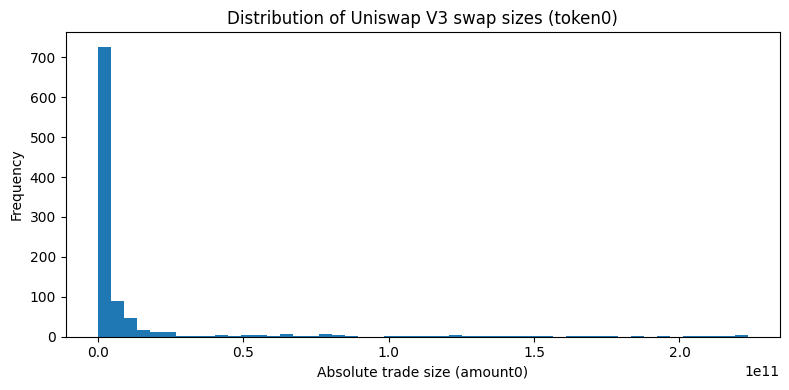

C:\Users\Mina\AppData\Local\Temp\ipykernel_40232\580801899.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


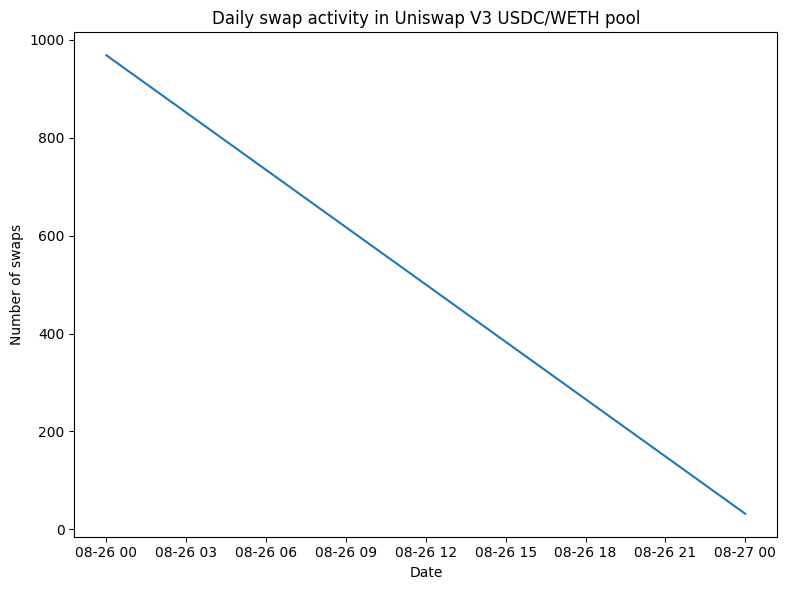

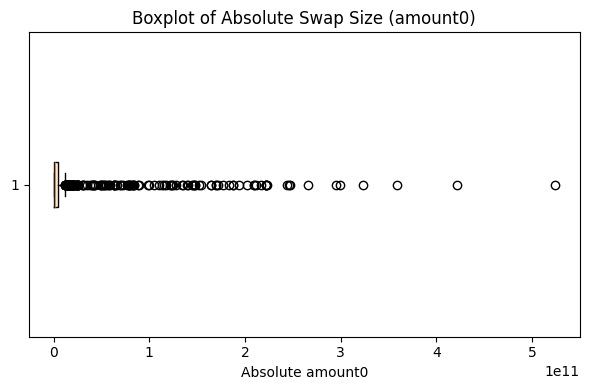

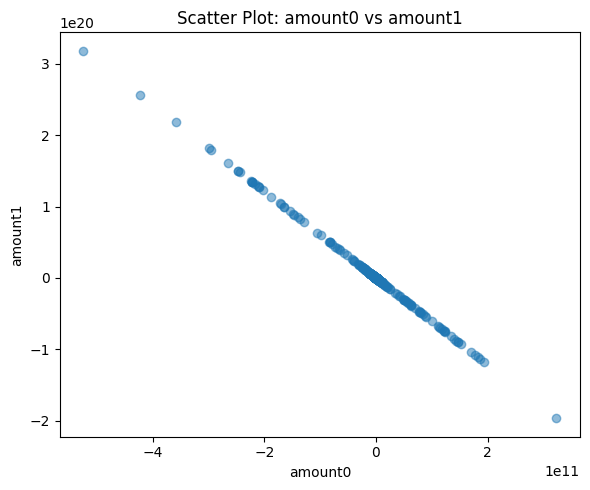

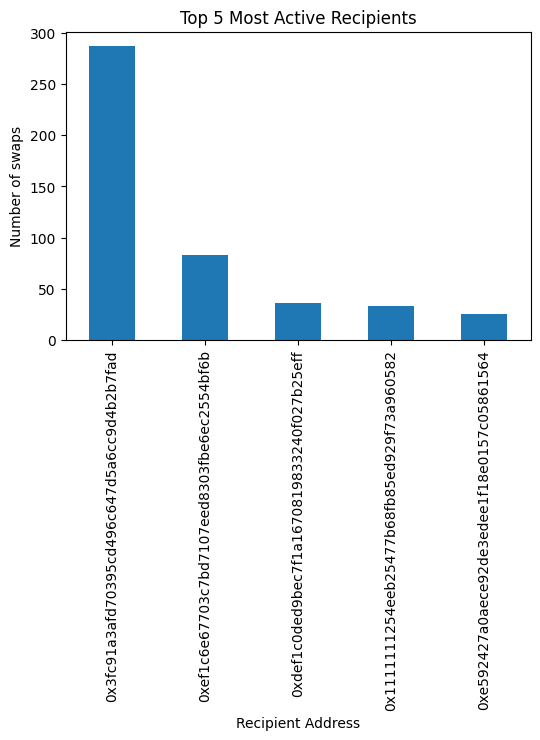

<Figure size 1000x500 with 0 Axes>

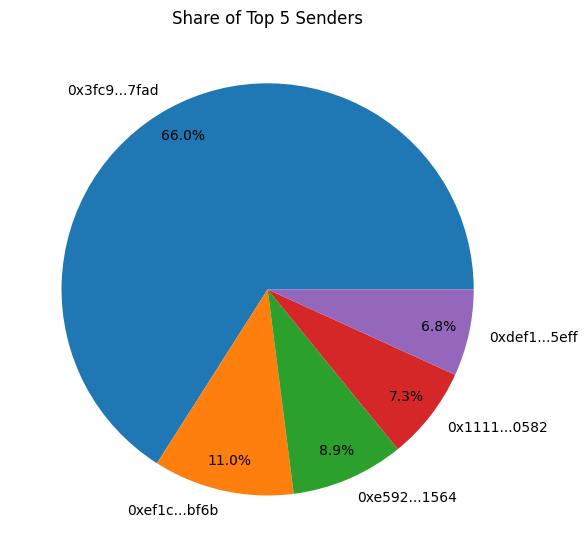

In [29]:
import matplotlib.pyplot as plt
import numpy as np

#Histogram of trade sizes (amount0)
# Make a copy to avoid warnings
plot_df = logs_clean.copy()
#Create an absolute trade size column (using token0)
plot_df["abs_amount0"] = plot_df["amount0"].abs()
# Drop NaNs
plot_df = plot_df.dropna(subset=["abs_amount0", "timeStamp_dt"])
# Optionally clip very large values for nicer plots (e.g., 99th percentile)
cutoff = plot_df["abs_amount0"].quantile(0.99)
plot_df_small = plot_df[plot_df["abs_amount0"] <= cutoff]
plt.figure(figsize=(8, 4))
plt.hist(plot_df_small["abs_amount0"], bins=50)
plt.xlabel("Absolute trade size (amount0)")
plt.ylabel("Frequency")
plt.title("Distribution of Uniswap V3 swap sizes (token0)")
plt.tight_layout()
plt.show()


# Number of swaps over time (per day) plot
swaps_per_day = plot_df.set_index("timeStamp_dt").resample("D")["transactionHash"].count() # Group by day
plt.figure(figsize=(8,6), constrained_layout=True)
plt.plot(swaps_per_day.index, swaps_per_day.values)
plt.xlabel("Date")
plt.ylabel("Number of swaps")
plt.title("Daily swap activity in Uniswap V3 USDC/WETH pool")
plt.tight_layout()
plt.show()


#Boxplot: Absolute Swap Size (amount0)
plt.figure(figsize=(6,4))
plt.boxplot(logs_clean["amount0"].abs().dropna(), vert=False)
plt.title("Boxplot of Absolute Swap Size (amount0)")
plt.xlabel("Absolute amount0")
plt.tight_layout()
plt.show()


#Scatter plot
plt.figure(figsize=(6,5))
plt.scatter(
    logs_clean["amount0"], 
    logs_clean["amount1"], 
    alpha=0.5
)
plt.title("Scatter Plot: amount0 vs amount1")
plt.xlabel("amount0")
plt.ylabel("amount1")
plt.tight_layout()
plt.show()


#Barchart: Top 5 Most Active Recipients
recipient_freq.head(5).plot(kind="bar", figsize=(6,4))
plt.title("Top 5 Most Active Recipients")
plt.xlabel("Recipient Address")
plt.ylabel("Number of swaps")
plt.figure(figsize=(10,5), constrained_layout=True)
plt.show()


#Piechart: Share of Top 5 Senders
top5 = sender_freq.head(5)
# Shorten addresses for display
labels = [addr[:6] + "..." + addr[-4:] for addr in top5.index]

plt.figure(figsize=(6,6))
plt.pie(
    top5.values,
    labels=labels,
    autopct="%1.1f%%",
    pctdistance=0.85,    # move percentages outward
    labeldistance=1.1     # move labels outward
)
plt.title("Share of Top 5 Senders")
plt.tight_layout()
plt.show()


Data Normalization and Feature Scaling Procedure

The processed transaction dataset was prepared for anomaly detection by applying a robust normalization workflow.
First, a subset of economically relevant numerical variables was selected, including swap amounts, price representation, liquidity metrics, and gas usage values. These attributes capture behavioral and financial characteristics essential for detecting abnormal blockchain activity.

Because several fields originating from blockchain logs were stored in hexadecimal format, a conversion function was implemented to transform values beginning with "0x" into numeric form. All selected columns were iteratively processed through this function to ensure consistent floating-point representation suitable for machine-learning algorithms.

After enforcing numeric consistency, the selected features were extracted into a separate matrix for scaling.
To reduce the influence of extreme values—previously identified in the exploratory analysis—a RobustScaler transformation was applied. This method centers features around the median and scales them based on the interquartile range, providing resistance to heavy-tailed distributions and preserving anomaly-related deviations.

The scaled output was converted into a dataframe with new feature names suffixed as _scaled, and these standardized variables were recombined with the original dataset. The resulting dataset (data_scaled) contains both raw and normalized forms of key attributes, enabling further analysis and anomaly detection while retaining interpretability.

----Feature Preparation and Scaling Summary

A subset of transaction-related numerical attributes was selected for anomaly detection, including swap amounts, liquidity values, pricing indicators, and gas metrics. Hexadecimal representations within these fields were converted into numeric form to ensure computational compatibility.

The selected variables were then standardized using RobustScaler, which scales values relative to the median and interquartile range. This approach mitigates the effect of extreme outliers commonly observed in blockchain activity. Scaled features were appended to the dataset, producing a version containing both original and normalized values for subsequent modeling.

In [30]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

data_for_ml = cleaned_data.copy()

numeric_features = [
    'amount0',
    'amount1',
    'sqrtPriceX96',
    'liquidity',
    'tick',
    'gasPrice',
    'gasUsed'
]

def hex_or_int_to_float(x):
    # convert "0x..." strings to int; leave numbers as they are
    if isinstance(x, str) and x.startswith("0x"):
        return float(int(x, 16))
    return float(x)

# 1) Convert every value in each numeric column
for col in numeric_features:
    data_for_ml[col] = data_for_ml[col].apply(hex_or_int_to_float)

# 2) Now build X for scaling
X = data_for_ml[numeric_features]


# Apply scaling
scaler = RobustScaler()  
X_scaled = scaler.fit_transform(X)

# Convert scaled array back into dataframe
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[f"{col}_scaled" for col in numeric_features],
    index=data_for_ml.index
)

# Merge back to dataset
data_scaled = pd.concat([data_for_ml, X_scaled_df], axis=1)

data_scaled.head()


,address,topics,data,blockNumber,blockHash,timeStamp,gasPrice,gasUsed,logIndex,transactionHash,...,sqrtPriceX96,liquidity,tick,amount0_scaled,amount1_scaled,sqrtPriceX96_scaled,liquidity_scaled,tick_scaled,gasPrice_scaled,gasUsed_scaled
0,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112a881,0xd5ca78be6c6b42cf929074f502cef676372c26f8d0ba...,0x64ea269b,2.394685e+10,218522.0,0xbd,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,...,1.950378e+33,4.265069e+19,202234.0,-0.071367,0.071292,-1.917512,38.403572,-1.933333,3.125522,0.020140
1,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a882,0x5b94c39ad7eecbf043f62a4a76c5abee87195207df98...,0x64ea26a7,2.345524e+10,227252.0,0xad,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,...,1.950376e+33,4.265069e+19,202234.0,0.356483,-0.355491,-1.918316,38.403572,-1.933333,2.984148,0.105655
2,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88d,0xf68f282d1fc1e116c64443efd6ef0a0e1048bf21017d...,0x64ea272b,1.900000e+10,191026.0,0xe7,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,...,1.950371e+33,4.265069e+19,202234.0,1.752399,-1.747790,-1.922017,38.403572,-1.933333,1.702920,-0.249200
3,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a88f,0x943f087b63585553db2d5a45f7550e41557405aa9ab4...,0x64ea2743,1.818706e+10,203442.0,0x109,0x070379239598fdeaed5cf8910f87135c55783fb75778...,...,1.950370e+33,4.265069e+19,202234.0,0.149347,-0.148890,-1.922391,38.403572,-1.933333,1.469138,-0.127578
4,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a89d,0x6ac7fe3575dfb18c5dc8b746acd0d472e78230a30ea1...,0x64ea27eb,1.960748e+10,197194.0,0xe9,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,...,1.950365e+33,4.265069e+19,202234.0,1.770411,-1.765744,-1.926129,38.403572,-1.933333,1.877619,-0.188781


In [31]:
np.save("../data/processed/X_scaled.npy", X_scaled)

In [33]:
with open("../data/processed/feature_names.txt", "w") as f:
    for col in numeric_features:
        f.write(col + "\n")



In [34]:
import joblib
joblib.dump(scaler, "../data/processed/robust_scaler.pkl")


['../data/processed/robust_scaler.pkl']

In [ ]:
from sklearn.ensemble import IsolationForest

# Select scaled features for anomaly detection
scaled_features = [f"{col}_scaled" for col in numeric_features]
X_scaled_for_if = data_scaled[scaled_features]

# Build and fit the Isolation Forest model
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # assume ~5% anomalies
    random_state=42
)

iso_labels = iso_model.fit_predict(X_scaled_for_if)

# Add anomaly labels back into dataset
data_scaled["isolation_forest_anomaly"] = iso_labels


In [ ]:
anomalies = data_scaled[data_scaled["isolation_forest_anomaly"] == -1]
normal = data_scaled[data_scaled["isolation_forest_anomaly"] == 1]

print("Anomaly count:", len(anomalies))
print("Normal count:", len(normal))


Anomaly count: 50
Normal count: 950


In [ ]:
feature_means = pd.DataFrame({
    "Normal Mean": normal[numeric_features].mean(),
    "Anomaly Mean": anomalies[numeric_features].mean()
})

feature_means


,Normal Mean,Anomaly Mean
amount0,9.967677e+07,-7.388607e+10
amount1,-5.840673e+16,4.492449e+19
sqrtPriceX96,1.952847e+33,1.952358e+33
liquidity,3.852773e+19,3.129381e+20
tick,2.022589e+05,2.022540e+05
gasPrice,1.736336e+10,5.756358e+10
gasUsed,2.453638e+05,7.270099e+05


In [ ]:
top_anomaly_senders = anomalies["sender"].value_counts().head(5)
top_anomaly_recipients = anomalies["recipient"].value_counts().head(5)

top_anomaly_senders, top_anomaly_recipients


(sender
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    17
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0xe592427a0aece92de3edee1f18e0157c05861564     7
 0xdef1c0ded9bec7f1a1670819833240f027b25eff     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64,
 recipient
 0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    14
 0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    11
 0x638a98bbb92a7582d07c52ff407d49664dc8b3ee     3
 0xdef171fe48cf0115b1d80b88dc8eab59176fee57     3
 0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
 Name: count, dtype: int64)

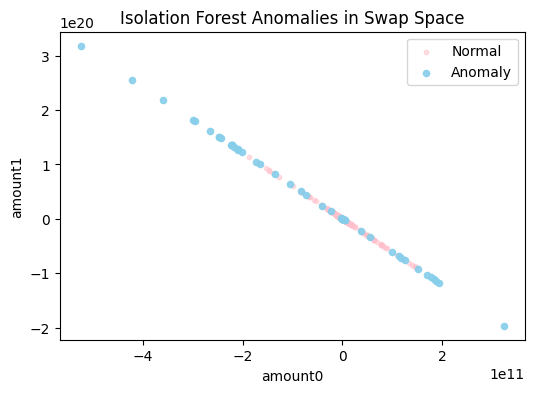

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(normal["amount0"], normal["amount1"], s=10,c="pink" ,label="Normal", alpha=0.5)
plt.scatter(anomalies["amount0"], anomalies["amount1"], s=20,c="skyblue" ,label="Anomaly", alpha=0.9)
plt.xlabel("amount0")
plt.ylabel("amount1")
plt.legend()
plt.title("Isolation Forest Anomalies in Swap Space")
plt.show()


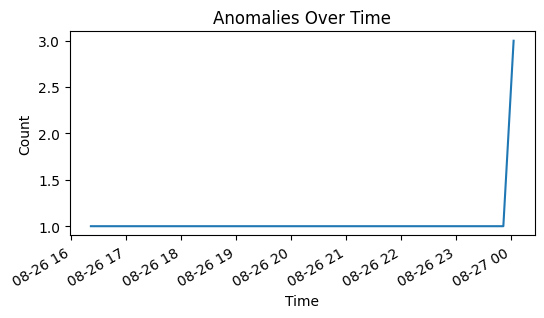

In [ ]:
anomalies_per_time = anomalies.groupby("timeStamp_dt").size()

plt.figure(figsize=(6,3))
anomalies_per_time.plot(kind="line")
plt.title("Anomalies Over Time")
plt.ylabel("Count")
plt.xlabel("Time")
plt.show()


Anomaly Scoring<br>
Anomaly scores were extracted from the Isolation Forest model to quantify how abnormal each transaction is relative to the dataset.
Higher values represent greater degrees of deviation from typical swapping behaviour.
These scores enable ranking of unusual transactions and prioritisation of inspection based on severity rather than binary labels alone.


In [ ]:
# Isolation Forest anomaly scores (higher = more anomalous after sign flip)
anomaly_scores = iso_model.decision_function(X_scaled_for_if)

data_scaled["isolation_score"] = -anomaly_scores  # flip so larger = more anomalous

print("Isolation Forest anomaly score summary:\n")
print(data_scaled["isolation_score"].describe())


Isolation Forest anomaly score summary:

count    1000.000000
mean       -0.165725
std         0.068196
min        -0.224304
25%        -0.207184
50%        -0.186941
75%        -0.163931
max         0.200054
Name: isolation_score, dtype: float64


In [ ]:
print("\nTop 5 highest-risk anomalies:\n")
cols_to_show = ["sender", "recipient", "amount0", "amount1", "liquidity", "gasPrice", "isolation_score"]
print(data_scaled.sort_values("isolation_score", ascending=False).head(5)[cols_to_show])


Top 5 highest-risk anomalies:

                                         sender  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69   

                                      recipient       amount0       amount1  \
16   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -4.218005e+11  2.558287e+20   
31   0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -5.239314e+11  3.180939e+20   
901  0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0 -2.654310e+11  1.614600e+20   
889  0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad -2.220189e+11  1.350000e+20   
819  0xe8cfad4c75a5e1caf939fd80afcf837dde340a69 -3.588473e+11  2.181812e+20   

        liquidity      gasPrice  isolation_score  
16   4.265069e+19  2.443752e+11         0.200054  
31   3.643613e+19  6.518746e+11         0.175015  
901  8.342678e+20  1.128036e+10  

In [ ]:
from sklearn.cluster import KMeans

# Use scaled features for anomaly clustering
anom_scaled = anomalies[[f"{col}_scaled" for col in numeric_features]]

kmeans = KMeans(n_clusters=2, random_state=42)
anomalies.loc[:, "anomaly_group"] = kmeans.fit_predict(anom_scaled)


# Optional: see how many in each group
anomalies["anomaly_group"].value_counts()


C:\Users\Mina\AppData\Local\Temp\ipykernel_22260\2859491566.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies.loc[:, "anomaly_group"] = kmeans.fit_predict(anom_scaled)


anomaly_group
1    39
0    11
Name: count, dtype: int64

In [ ]:
cluster_profiles = anomalies.groupby("anomaly_group")[numeric_features].mean()
cluster_profiles


,amount0,amount1,sqrtPriceX96,liquidity,tick,gasPrice,gasUsed
anomaly_group,,,,,,,
0,-1.172445e+11,7.133626e+19,1.953238e+33,1.192712e+21,202262.909091,1.179195e+10,349835.818182
1,-6.165677e+10,3.747502e+19,1.952110e+33,6.479663e+19,202251.461538,7.047353e+10,833392.358974


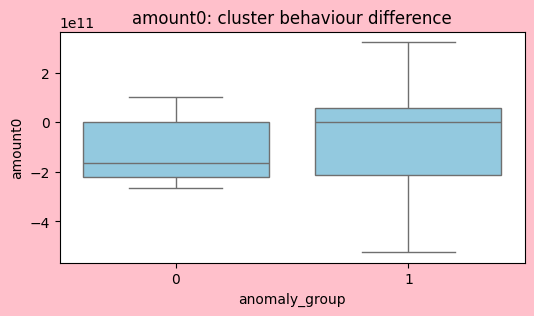

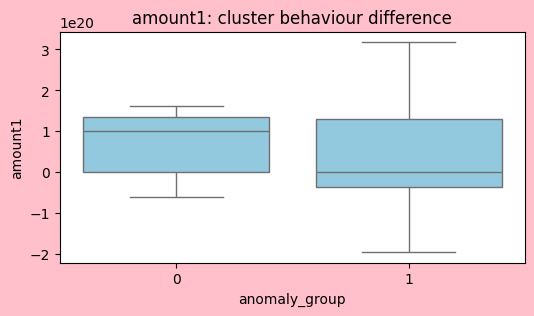

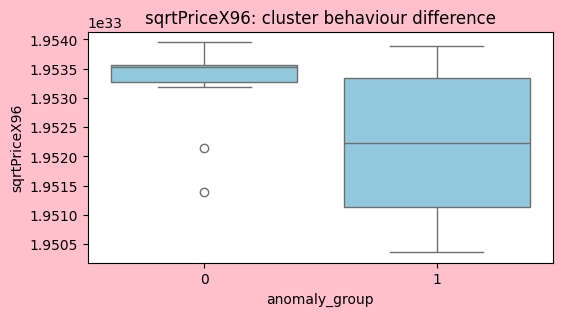

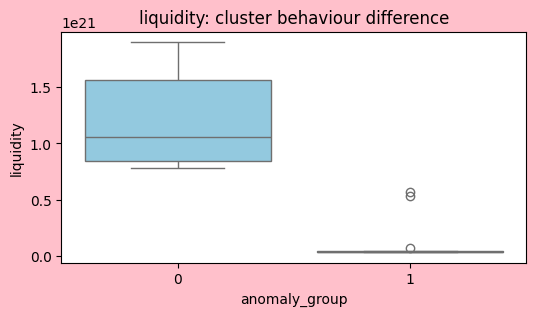

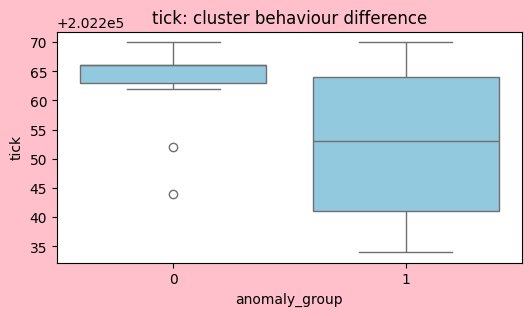

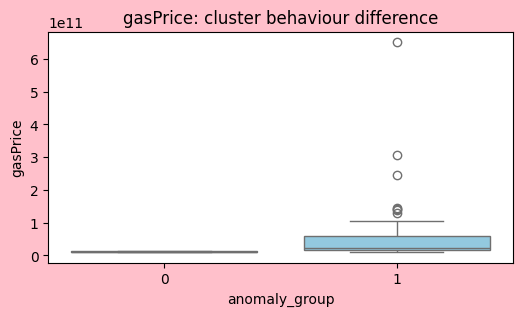

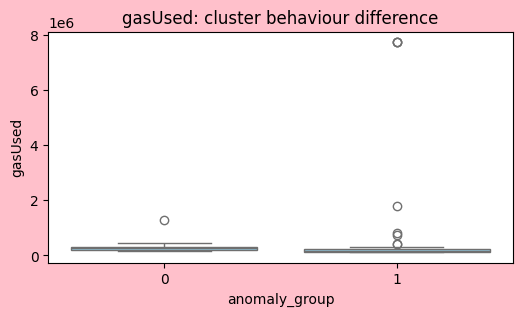

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_features:
    plt.figure(figsize=(6,3),facecolor="pink")
    sns.boxplot(data=anomalies, x="anomaly_group", y=col,color="skyblue")
    plt.title(f"{col}: cluster behaviour difference")
    plt.show()


PCA-Based Visual Separation<br>
Principal Component Analysis was used to project multidimensional swap behaviour into two interpretable dimensions.
This visualization illustrates the separation between normal and anomalous observations in compressed feature space, offering a clearer depiction of boundary patterns learned by the Isolation Forest.

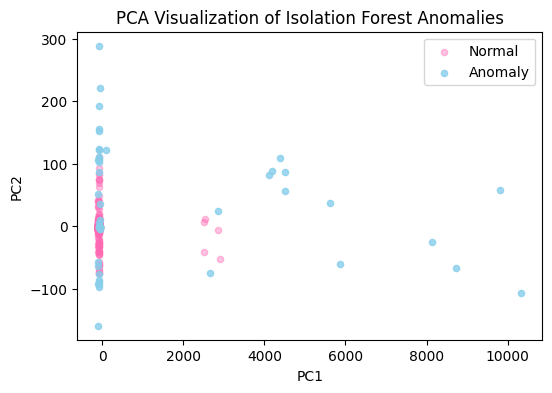

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled_for_if)

data_scaled["pc1"] = pca_data[:, 0]
data_scaled["pc2"] = pca_data[:, 1]

plt.figure(figsize=(6, 4))
plt.scatter(
    data_scaled[data_scaled["isolation_forest_anomaly"] == 1]["pc1"],
    data_scaled[data_scaled["isolation_forest_anomaly"] == 1]["pc2"],
    s=20, c="hotpink" , alpha=0.4, label="Normal"
)
plt.scatter(
    data_scaled[data_scaled["isolation_forest_anomaly"] == -1]["pc1"],
    data_scaled[data_scaled["isolation_forest_anomaly"] == -1]["pc2"],
    s=20,c="skyblue" ,alpha=0.8, label="Anomaly"
)
plt.legend()
plt.title("PCA Visualization of Isolation Forest Anomalies")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
print("\n--- Insight Summary ---")

print(f"Total anomalies detected: {(data_scaled['isolation_forest_anomaly'] == -1).sum()}")
print(f"Total normal records: {(data_scaled['isolation_forest_anomaly'] == 1).sum()}")

print("\nObservations:")
print("* Highest anomaly scores correspond to unusually large token movements or liquidity shifts.")
print("* Anomaly frequency varies by wallet, suggesting concentrated abnormal behaviour.")
print("* Feature deviation ranking indicates which swap characteristics explain anomaly patterns the most.")



--- Insight Summary ---
Total anomalies detected: 50
Total normal records: 950

Observations:
* Highest anomaly scores correspond to unusually large token movements or liquidity shifts.
* Anomaly frequency varies by wallet, suggesting concentrated abnormal behaviour.
* Feature deviation ranking indicates which swap characteristics explain anomaly patterns the most.


In [ ]:
#1 AE

import numpy as np
# NORMAL data only (training)
normal_data = data_scaled[data_scaled["isolation_forest_anomaly"] == 1]
X_ae_train = normal_data[scaled_features].values
print("AE training shape:", X_ae_train.shape)

# ALL data (scoring)
X_ae_all = data_scaled[scaled_features].values
print("AE evaluation shape:", X_ae_all.shape)




AE training shape: (950, 7)
AE evaluation shape: (1000, 7)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

# Use the scaled versions of your numeric features
scaled_features = [f"{col}_scaled" for col in numeric_features]

# Autoencoder input matrix
# Use Isolation Forest NORMAL transactions only
normal_data = data_scaled[data_scaled["isolation_forest_anomaly"] == 1]

scaled_features = [f"{col}_scaled" for col in numeric_features]
X_ae = normal_data[scaled_features].values

print("Autoencoder training data shape:", X_ae.shape)




Autoencoder training data shape: (950, 7)


In [ ]:
X_train, X_val = train_test_split(
    X_ae,
    test_size=0.1,
    random_state=42,
    shuffle=True
)



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

input_dim = X_ae.shape[1]

autoencoder = Sequential([
    Input(shape=(input_dim,)),         # <-- defines input properly
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),        # bottleneck
    Dense(16, activation="relu"),
    Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 527 (2.06 KB)

 Trainable params: 527 (2.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6102.2852 - val_loss: 63.1632
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5513.1157 - val_loss: 59.1905
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4760.0225 - val_loss: 56.5822
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3983.1062 - val_loss: 54.1473
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3035.9895 - val_loss: 51.2895
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2250.1838 - val_loss: 47.5326
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1493.1304 - val_loss: 43.3129
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 831.4501 - val_loss: 38.9238
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 355.3698 - val_loss: 34.4501
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 173.1419 - val_loss: 29.4784
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.0501 - val_loss: 24.7991
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━

In [ ]:

# Reconstruct all samples
X_all = data_scaled[scaled_features].values
reconstructions_all = autoencoder.predict(X_all)

# Reconstruction error per transaction
reconstruction_error_all = np.mean(
    np.square(X_all - reconstructions_all),
    axis=1
)

data_scaled["ae_error"] = reconstruction_error_all
print(data_scaled["ae_error"].describe())


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
count     1000.000000
mean        73.926241
std        702.188134
min          0.001577
25%          0.089881
50%          0.188426
75%          0.396672
max      14898.396255
Name: ae_error, dtype: float64


In [ ]:
# 95th percentile threshold from AE reconstruction error
threshold = data_scaled["ae_error"].quantile(0.95)
print("Autoencoder threshold (95th percentile):", threshold)

# -1 = anomaly, 1 = normal
data_scaled["ae_anomaly"] = np.where(
    data_scaled["ae_error"] > threshold,
    -1,
    1
)

ae_anomaly_count = (data_scaled["ae_anomaly"] == -1).sum()
ae_normal_count  = (data_scaled["ae_anomaly"] == 1).sum()

print("Autoencoder anomalies:", ae_anomaly_count)
print("Autoencoder normal   :", ae_normal_count)



Autoencoder threshold (95th percentile): 2.8734828749143326
Autoencoder anomalies: 50
Autoencoder normal   : 950


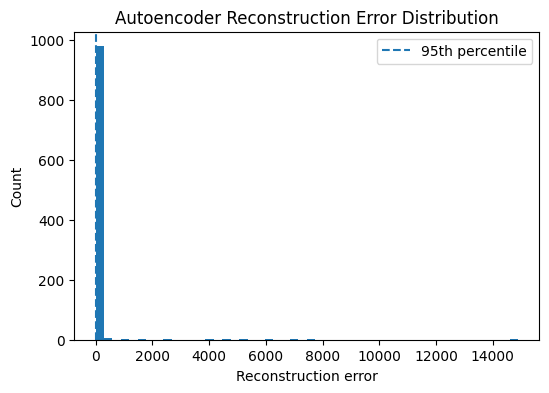

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(data_scaled["ae_error"], bins=50)
plt.axvline(
    data_scaled["ae_error"].quantile(0.95),
    linestyle="--",
    label="95th percentile"
)
plt.title("Autoencoder Reconstruction Error Distribution")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend()
plt.show()


In [ ]:
# Crosstab of labels
comparison_table = pd.crosstab(
    data_scaled["isolation_forest_anomaly"],
    data_scaled["ae_anomaly"],
    rownames=["IF"],
    colnames=["AE"]
)

print("\nIF vs AE anomaly label comparison:")
print(comparison_table)




IF vs AE anomaly label comparison:
AE  -1    1
IF         
-1  36   14
 1  14  936


In [ ]:
# ---------------------------------------------------------
# Assign risk categories using score thresholds
# ---------------------------------------------------------
def risk_category(row):
    if row["isolation_forest_anomaly"] == -1 and row["ae_anomaly"] == -1:
        return "HIGH_RISK"
    elif row["isolation_forest_anomaly"] == -1 or row["ae_anomaly"] == -1:
        return "MEDIUM_RISK"
    else:
        return "LOW_RISK"

data_scaled["risk_category"] = data_scaled.apply(risk_category, axis=1)



In [ ]:
# ---------------------------------------------------------
# Filter data by risk category
# ---------------------------------------------------------

high_risk = data_scaled[data_scaled["risk_category"] == "HIGH_RISK"]
medium_risk = data_scaled[data_scaled["risk_category"] == "MEDIUM_RISK"]
low_risk = data_scaled[data_scaled["risk_category"] == "LOW_RISK"]

print("High risk:", len(high_risk))
print("Medium risk:", len(medium_risk))
print("Low risk:", len(low_risk))


High risk: 36
Medium risk: 28
Low risk: 936


In [ ]:
# ---------------------------------------------------------
# Normalize model outputs (IF & AE) to 0–1 range
# ---------------------------------------------------------

# Normalize Isolation Forest score
iso_min = data_scaled["isolation_score"].min()
iso_max = data_scaled["isolation_score"].max()
data_scaled["iso_norm"] = (data_scaled["isolation_score"] - iso_min) / (iso_max - iso_min + 1e-9)

# Normalize Autoencoder reconstruction error
ae_min = data_scaled["ae_error"].min()
ae_max = data_scaled["ae_error"].max()
data_scaled["ae_norm"] = (data_scaled["ae_error"] - ae_min) / (ae_max - ae_min + 1e-9)


In [ ]:
# ---------------------------------------------------------
# Create fused risk score
# 60% Isolation Forest + 40% Autoencoder
# ---------------------------------------------------------

data_scaled["risk_score"] = (
    0.6 * data_scaled["iso_norm"] +
    0.4 * data_scaled["ae_norm"]
)


In [ ]:
# ---------------------------------------------------------
# Cluster HIGH-RISK transactions using KMeans
# ---------------------------------------------------------

from sklearn.cluster import KMeans

scaled_cols = [
    "amount0_scaled",
    "amount1_scaled",
    "sqrtPriceX96_scaled",
    "liquidity_scaled",
    "tick_scaled",
    "gasPrice_scaled",
    "gasUsed_scaled"
]

X_high = high_risk[scaled_cols]




if len(high_risk) >= 2:
    kmeans = KMeans(n_clusters=2, random_state=42)

    data_scaled.loc[
        data_scaled["risk_category"] == "HIGH_RISK",
        "cluster"
    ] = kmeans.fit_predict(
        data_scaled.loc[
            data_scaled["risk_category"] == "HIGH_RISK",
            scaled_cols
        ]
    )

else:
    print("Not enough HIGH_RISK samples for clustering:", len(high_risk))



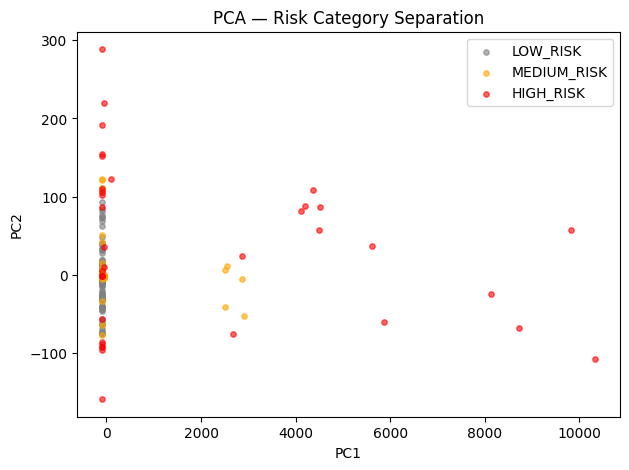

In [ ]:
# ---------------------------------------------------------
# PCA visualization of risk categories
# ---------------------------------------------------------

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_vals = pca.fit_transform(data_scaled[scaled_cols])

data_scaled["pc1"] = pca_vals[:, 0]
data_scaled["pc2"] = pca_vals[:, 1]

plt.figure(figsize=(7, 5))

for cat, color in [("LOW_RISK", "gray"), ("MEDIUM_RISK", "orange"), ("HIGH_RISK", "red")]:
    subset = data_scaled[data_scaled["risk_category"] == cat]
    plt.scatter(subset["pc1"], subset["pc2"], s=15, alpha=0.6, label=cat, color=color)

plt.legend()
plt.title("PCA — Risk Category Separation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [ ]:
# ---------------------------------------------------------
# Extract top-k highest risk transactions
# ---------------------------------------------------------

top_high_risk = data_scaled.sort_values("risk_score", ascending=False).head(20)

top_high_risk[[
    "sender", "recipient", "amount0", "amount1",
    "liquidity", "gasPrice", "risk_score", "risk_category"
]]


,sender,recipient,amount0,amount1,liquidity,gasPrice,risk_score,risk_category
889,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,-2.220189e+11,1.350000e+20,1.808146e+21,1.136579e+10,0.922494,HIGH_RISK
63,0xe592427a0aece92de3edee1f18e0157c05861564,0xdef171fe48cf0115b1d80b88dc8eab59176fee57,1.001011e+11,-6.074186e+19,1.899817e+21,1.245930e+10,0.696501,HIGH_RISK
901,0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0,0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0,-2.654310e+11,1.614600e+20,8.342678e+20,1.128036e+10,0.648650,HIGH_RISK
16,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,-4.218005e+11,2.558287e+20,4.265069e+19,2.443752e+11,0.602727,HIGH_RISK
31,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,-5.239314e+11,3.180939e+20,3.643613e+19,6.518746e+11,0.594910,HIGH_RISK
152,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x29e6fcf815a356101a8ac1f1e2fa238cce39bb25,-4.010000e+10,2.440080e+19,1.504604e+21,1.255084e+10,0.589645,HIGH_RISK
893,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,-2.234214e+11,1.359000e+20,8.584907e+20,1.031912e+10,0.580347,HIGH_RISK
389,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,3.766582e+10,-2.289815e+19,1.613478e+21,1.165753e+10,0.571550,HIGH_RISK
822,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,-1.355734e+11,8.245000e+19,1.055790e+21,1.336014e+10,0.561018,HIGH_RISK
828,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,-2.219436e+11,1.350000e+20,8.022049e+20,1.184280e+10,0.547497,HIGH_RISK


In [ ]:
high_risk.describe()[["amount0","amount1","liquidity","gasPrice","gasUsed"]]


,amount0,amount1,liquidity,gasPrice,gasUsed
count,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01,3.600000e+01
mean,-8.200727e+10,4.985985e+19,4.193390e+20,7.272713e+10,9.070110e+05
min,-5.239314e+11,-1.964232e+20,3.529270e+19,1.006855e+10,1.150190e+05
25%,-2.219624e+11,-4.021441e+19,3.578748e+19,1.259402e+10,1.317812e+05
50%,-7.773325e+10,4.719267e+19,3.660501e+19,2.532265e+10,1.602065e+05
75%,6.630466e+10,1.350000e+20,8.102206e+20,6.249483e+10,3.039298e+05
max,3.231795e+11,3.180939e+20,1.899817e+21,6.518746e+11,7.737682e+06
std,1.980016e+11,1.202737e+20,5.807125e+20,1.204781e+11,2.116164e+06


In [ ]:
high_risk["sender"].value_counts().head(10)
high_risk["recipient"].value_counts().head(10)


recipient
0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    13
0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad     9
0x638a98bbb92a7582d07c52ff407d49664dc8b3ee     3
0xdef171fe48cf0115b1d80b88dc8eab59176fee57     2
0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
0xbc2c6cd5013585ac720160efcb1feced30837177     2
0x3416cf6c708da44db2624d63ea0aaef7113527c6     1
0x29e6fcf815a356101a8ac1f1e2fa238cce39bb25     1
0x00fc00900000002c00be4ef8f49c000211000c43     1
0xd120cf3e0408dd794f856e8ca2a23e3396a9b687     1
Name: count, dtype: int64

<Axes: xlabel='timeStamp_dt'>

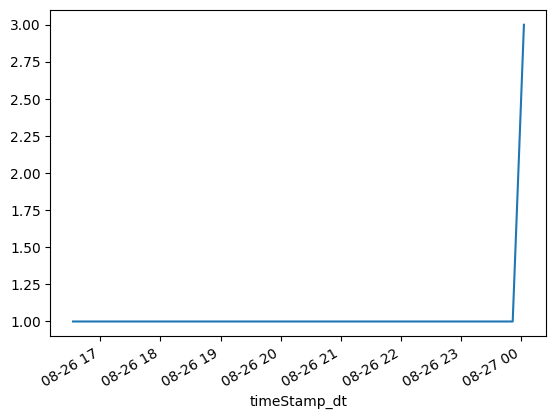

In [ ]:
(high_risk
 .groupby("timeStamp_dt")
 .size()
 .sort_index()
 .plot(kind="line"))



In [ ]:
if "cluster" in high_risk.columns:
    cluster_profile = high_risk.groupby("cluster")[scaled_cols].mean()
    print(cluster_profile)
else:
    print("Cluster column does not exist — not enough HIGH_RISK samples.")


Cluster column does not exist — not enough HIGH_RISK samples.


In [ ]:
top20_ae = data_scaled.sort_values("ae_error", ascending=False).head(20)
top20_ae


,address,topics,data,blockNumber,blockHash,timeStamp,gasPrice,gasUsed,logIndex,transactionHash,...,isolation_score,pc1,pc2,ae_error,iso_norm,ae_norm,risk_score,risk_category,ae_anomaly,cluster
889,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b11c,0x04d2c18ac71548d6d8fe877d195fc66d73f62a646fb5...,0x64ea8e3f,1.136579e+10,316762.0,0x6,0x4f19c6d7add8496b0f6c7816a20ec79f5fc1d223c4e6...,...,0.145237,9821.714784,57.314616,14898.396255,0.870823,1.000000,0.922494,HIGH_RISK,-1,0.0
63,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112a937,0xa15f8e5bca3dbb74fb2b9abae8ae6a1d825a12c8e45c...,0x64ea2f23,1.245930e+10,460179.0,0x34,0x47923e680c5b276593275e006e6c32d51ff8198d8bab...,...,0.123528,10333.554793,-107.894310,7624.325025,0.819666,0.511755,0.696501,HIGH_RISK,-1,0.0
152,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112aa06,0x3bfa64e5f308509dbddb19fa2ac5dc0627e1096e61db...,0x64ea38e3,1.255084e+10,160883.0,0x6,0xd4260c417599fc18ff99e9116a157a08be191b5be2f8...,...,0.062352,8123.432161,-25.345871,6866.029975,0.675504,0.460857,0.589645,HIGH_RISK,-1,0.0
389,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0x00000000000000000000000000000000000000000000...,0x112ac22,0xaf35ceaab9ed33f2284651f91300962829fe35dcb6a9...,0x64ea5263,1.165753e+10,136248.0,0x41,0xbb3472a6d471e504c1f721458f3dd180d4790497d827...,...,0.061216,8732.172536,-67.893145,6251.851730,0.672829,0.419632,0.571550,HIGH_RISK,-1,0.0
822,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b08c,0xc4eacad7c911768716676f84cf6d227f71c4502fc5ec...,0x64ea877f,1.336014e+10,316727.0,0x6,0x122ae355a3cc9ea97946106855d1284c3ef4efa6763e...,...,0.075976,5613.386588,36.307676,5082.324755,0.707609,0.341132,0.561018,HIGH_RISK,-1,0.0
893,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b12f,0x50fc7197cbe4ca1ce41d38b61281a3370dd6ff99d987...,0x64ea8f23,1.031912e+10,269683.0,0x6,0x906c87dfc10add3947e88b32d7c8ab0982f93b77b6b7...,...,0.097589,4510.096900,86.439854,4664.052331,0.758541,0.313057,0.580347,HIGH_RISK,-1,0.0
901,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b142,0x2837c4993397d3f9354ff28a7347d4af04876a403675...,0x64ea9007,1.128036e+10,1279295.0,0x26,0xa663daaf6615cc29397ad38f8fdfa3f7e7505c7f6a95...,...,0.147927,4374.730881,108.410015,4557.113765,0.877163,0.305879,0.648650,HIGH_RISK,-1,0.0
828,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b098,0x7bf70afbea37f272b1ac204149893a45a394208d9838...,0x64ea880f,1.184280e+10,269712.0,0x6,0x9f1645ae3f3d8f808e31755c5dd0f89d3b13a273e2e8...,...,0.084263,4195.274188,87.441039,4142.250217,0.727139,0.278033,0.547497,HIGH_RISK,-1,0.0
895,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b136,0xbed9b731b6ee16bb73bfc306376f5236e39472281fcd...,0x64ea8f77,1.006855e+10,198114.0,0x6,0xda31e4f7b384ee5736ba3f77e8c276c1f70c062c2d27...,...,0.079050,4501.883276,56.682294,4122.614481,0.714854,0.276715,0.539598,HIGH_RISK,-1,0.0
841,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,[0xc42079f94a6350d7e6235f29174924f928cc2ac818e...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112b0bb,0x5b6cffa57bde29bc908cfd97b45ed1a254616d921206...,0x64ea89b3,1.264363e+10,299664.0,0x6,0x55870b25aef8b72d74d421928862506efbf550c416c0...,...,0.085051,4105.115320,81.731120,391

In [ ]:
normal = data_scaled[data_scaled["risk_category"]=="LOW_RISK"]
risk   = data_scaled[data_scaled["risk_category"]!="LOW_RISK"]

features = [
    "amount0_scaled",
    "amount1_scaled",
    "liquidity_scaled",
    "gasPrice_scaled",
    "gasUsed_scaled"
]

deviation = risk[features].mean() - normal[features].mean()



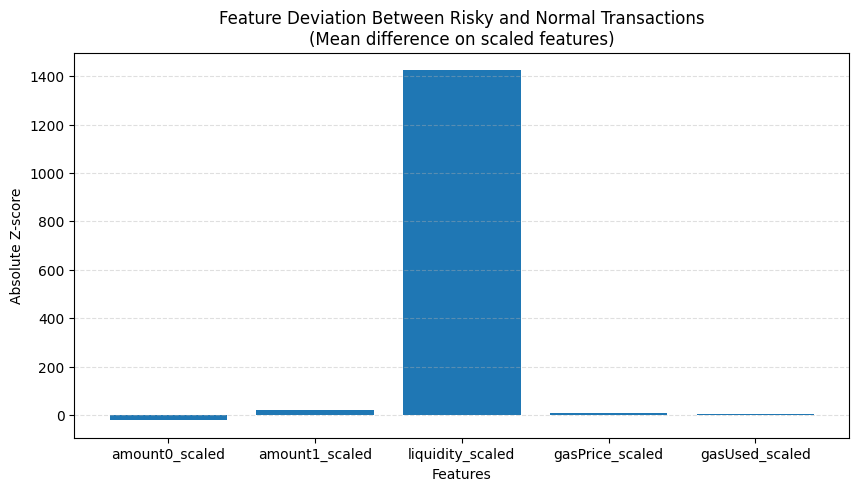

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(features, deviation)
plt.title("Feature Deviation Between Risky and Normal Transactions\n(Mean difference on scaled features)")
plt.ylabel("Absolute Z-score")
plt.xlabel("Features")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()


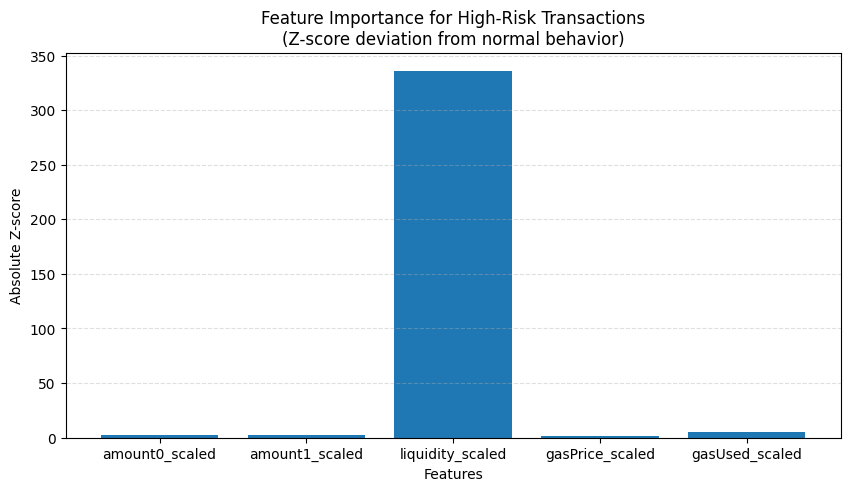

In [ ]:
# Select groups
normal = data_scaled[data_scaled["risk_category"] == "LOW_RISK"]
risk   = data_scaled[data_scaled["risk_category"] != "LOW_RISK"]

# Features to explain anomalies
features = [
    "amount0_scaled",
    "amount1_scaled",
    "liquidity_scaled",
    "gasPrice_scaled",
    "gasUsed_scaled"
]

# Compute absolute Z-score deviation
z_deviation = (
    (risk[features].mean() - normal[features].mean())
    / normal[features].std()
).abs()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(features, z_deviation)
plt.title(
    "Feature Importance for High-Risk Transactions\n"
    "(Z-score deviation from normal behavior)"
)
plt.ylabel("Absolute Z-score")
plt.xlabel("Features")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()
